<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Bhoomi Tulsiyani | 23010101275</b></center>
    
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 15</b></center>    
<pre>    

###
---
Introduction to Transfer Learning
In our previous lab, we built a Convolutional Neural Network (CNN) from scratch. While effective for simpler tasks, training deep networks from scratch requires massive datasets and significant computational power.

**Transfer Learning** allows us to take a model that has already been trained on a massive dataset (like ImageNet, which contains millions of images across 1000 categories) and repurpose it for our own specific task (like detecting malaria in cell images).

### Key Concepts:
1. **Pre-trained Model (The Base):** We will import **VGG16**, a famous and powerful deep CNN architecture. We will load the weights it learned from the ImageNet dataset.
2. **Importing the Model:** PyTorch provides built-in modules (`torchvision.models`) to download these architectures.
3. **Freezing Layers:** We "freeze" the base model (`requires_grad = False`) to keep its weights intact while we train only our new custom head.
4. **Replacing the Head:** Pre-trained models are typically designed to output 1000 classes. We will replace the final classification layers (the "head") with our own layers designed for binary classification.
5. **Fine-Tuning:** Once our custom head is trained, we can optionally "unfreeze" the top few layers of the base model and train the whole system with a very low learning rate.


### Task 1: Import Necessary Libraries
Import PyTorch, Torchvision, and other necessary libraries for data loading and visualization.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
import os
import urllib.request
import zipfile
import random
import shutil


dataset_url = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"
zip_path = "cell_images.zip"
original_dataset_dir = "cell_images"
base_dir = "./Malaria_Dataset"


if not os.path.exists(zip_path) and not os.path.exists(base_dir):
    print("Downloading Malaria dataset. Please wait...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    print("Download complete!")


if not os.path.exists(original_dataset_dir) and not os.path.exists(base_dir):
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction complete!")


if not os.path.exists(base_dir):
    print("Creating train/val split structure...")
    classes = ['Parasitized', 'Uninfected']

    # Create the folder structure
    for split in ['train', 'val']:
        for cls in classes:
            os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)


    split_ratio = 0.8
    for cls in classes:
        src_dir = os.path.join(original_dataset_dir, cls)
        filenames = os.listdir(src_dir)


        filenames = [f for f in filenames if f.endswith('.png')]


        random.shuffle(filenames)


        split_idx = int(len(filenames) * split_ratio)
        train_files = filenames[:split_idx]
        val_files = filenames[split_idx:]


        for f in train_files:
            shutil.copy(os.path.join(src_dir, f), os.path.join(base_dir, 'train', cls, f))


        for f in val_files:
            shutil.copy(os.path.join(src_dir, f), os.path.join(base_dir, 'val', cls, f))

    print("Dataset successfully organized into ./Malaria_Dataset/train and ./Malaria_Dataset/val")
else:
    print("Dataset already downloaded and organized!")

Download complete!
Extracting files...
Extraction complete!
Creating train/val split structure...
Dataset successfully organized into ./Malaria_Dataset/train and ./Malaria_Dataset/val



# PART 1

In [14]:
print("Loading VGG16...")
vgg16_full = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16_full = vgg16_full.to(device)
vgg16_full.eval()

Loading VGG16...


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [11]:
import json
import requests
import matplotlib.pyplot as plt
labels_url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
imagenet_labels = json.loads(requests.get(labels_url).text)

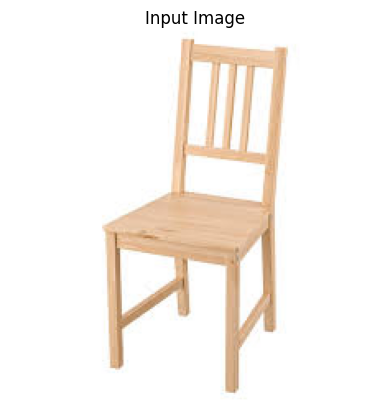

In [15]:
import io
import requests
from PIL import Image

img_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcShXCU7gvMEYA-tOoY_nYflTVkMy3DIuUMvFg&s"

response = requests.get(img_url)
img = Image.open(io.BytesIO(response.content))

plt.imshow(img)
plt.axis('off')
plt.title("Input Image")
plt.show()

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.255])
])

input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0).to(device)

In [16]:
with torch.no_grad():
  output = vgg16_full(input_batch)

probabilities = torch.nn.functional.softmax(output[0] , dim=0)
top3_prob , top3_catid = torch.topk(probabilities , 10)
for i in range(top3_prob.size(0)):
  class_name = imagenet_labels[top3_catid[i]]
  confidence = top3_prob[i].item()*100
  print(f"{i+1}. {class_name}: {confidence:.2f}%")

1. folding chair: 62.33%
2. dining table: 12.99%
3. desk: 5.99%
4. cradle: 3.14%
5. bassinet: 3.11%
6. rocking chair: 2.34%
7. pedestal: 2.31%
8. filing cabinet: 1.29%
9. infant bed: 1.05%
10. bookcase: 0.84%



# PART 2

### Task 2: Data Augmentation and Loading
Initialize transformations (rescaling to 0-1 via `ToTensor()`, resizing, and adding random augmentations). Use `datasets.ImageFolder` and `DataLoader` to load the Train and Test sets.

In [17]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(base_dir, x), data_transforms[x])
    for x in ['train', 'val']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=4)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Class names: {class_names}")
print(f"Training set size: {dataset_sizes['train']}")
print(f"Validation set size: {dataset_sizes['val']}")

Class names: ['Parasitized', 'Uninfected']
Training set size: 22046
Validation set size: 5512


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


### Task 3: Load Base Model and Freeze Layers
Load the pre-trained VGG16 model. Iterate through its parameters and turn off gradients so the weights don't update during the initial training phase.

In [18]:
# Load pre-trained VGG16
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

for param in vgg16.parameters():
  param.requires_grad = False

### Task 4: Add Custom Head (Classifier)
Replace `vgg16.classifier` with a new `nn.Sequential` block containing a Linear layer (e.g., 256 units), a ReLU activation, and a final Linear layer for our binary output.

In [19]:
num_features = vgg16.classifier[0].in_features


vgg16.classifier = nn.Sequential(
  nn.Linear(num_features , 256),
  nn.ReLU(),
  nn.Dropout(0.5),
  nn.Linear(256,len(class_name))
)


vgg16 = vgg16.to(device)


print(vgg16)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Task 5: Define Loss Function and Optimizer
Define the criterion (Loss Function). Set up the optimizer (e.g., Adam) to *only* update the parameters of the new classifier we just added.

In [20]:
criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opoosed to before.
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=0.001)

### Task 6: Train the Model
Create the PyTorch training loop. Iterate over the epochs, perform forward passes, calculate the loss, backpropagate, and update the optimizer steps. Keep track of training and validation accuracy.

In [22]:
num_epochs = 5

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    # Each epoch has a training and validation phase
    for phase in ['train', 'val']:
        if phase == 'train':
            vgg16.train()  # Set model to training mode
        else:
            vgg16.eval()   # Set model to evaluate mode

        running_loss = 0.0
        running_corrects = 0

        # Iterate over data.
        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward
            # track history if only in train
            with torch.set_grad_enabled(phase == 'train'):
                outputs = vgg16(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                # backward + optimize only if in training phase
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            # statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accuracies.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accuracies.append(epoch_acc.item())

print('\nTraining complete')

Epoch 1/5
----------
train Loss: 0.3766 Acc: 0.8318


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


val Loss: 0.2115 Acc: 0.9185
Epoch 2/5
----------
train Loss: 0.3573 Acc: 0.8452


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


val Loss: 0.1790 Acc: 0.9302
Epoch 3/5
----------
train Loss: 0.3459 Acc: 0.8508
val Loss: 0.1973 Acc: 0.9218
Epoch 4/5
----------
train Loss: 0.3545 Acc: 0.8431
val Loss: 0.1736 Acc: 0.9352
Epoch 5/5
----------
train Loss: 0.3494 Acc: 0.8480
val Loss: 0.1823 Acc: 0.9336

Training complete


### Task 7: Plot History
Visualize the Training vs. Validation Accuracy and Loss using Matplotlib to check for overfitting or underfitting.

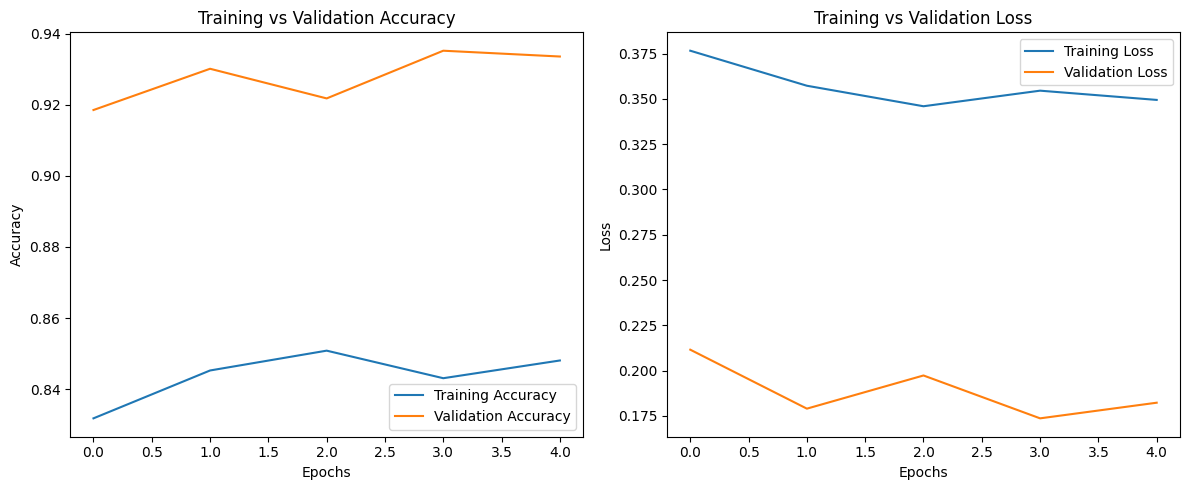

In [23]:
plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(range(len(train_accuracies)), train_accuracies, label='Training Accuracy')
plt.plot(range(len(val_accuracies)), val_accuracies, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(range(len(train_losses)), train_losses, label='Training Loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()